## Filtrage gaussien / Détection de contours / Détection de cercles
## Computer Vision
### Auteur : Loann KAIKA

In [26]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import convolve2d

img_circle_path = r"C:\Users\loann\Desktop\v793-ning-21.jpg"

(np.float64(-0.5), np.float64(4999.5), np.float64(4999.5), np.float64(-0.5))

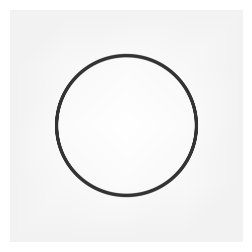

In [27]:
def read_image(img_path):
    image = cv2.imread(img_path)
    if image is None:
        raise FileNotFoundError(f"Image is not found at {img_path}")
    return image

circle = read_image(img_circle_path)

fig, axes = plt.subplots(figsize=(3,4)) 
axes.imshow(circle)
axes.axis('off')

### 1. Détection de cercle dans une image

Dans une image, les pixels ont des coordonnées $(x,y)$. Un cercle vérifie :
$$
(x-a)^2 + (y-b)^2 = r^2
$$

avec $a,b$ le centre du cercle et $r$ le rayon.

Le problème est que l’on ne connaît ni $a$ ni $b$ ni $r$.

La première étape est d’extraire les **contours** de l’image avec Canny.

#### **Détection de contours (Comment ça fonctionne ?)**

**1. Lissage gaussien (réduction du bruit)**
<br>
On applique un filtre gaussien pour lisser l'image et réduire le bruit et les faux bords

Exemple de masque (noyau gaussien) $5\times5$ discret avec $σ = 1,2$ :
$$
K = 
\frac{1}{159}
\begin{bmatrix}
2 & 4 & 5 & 4 & 2 \\
4 & 9 & 12 & 9 & 4 \\
5 & 12 & 15 & 12 & 5 \\
4 & 9 & 12 & 9 & 4 \\
2 & 4 & 5 & 4 & 2
\end{bmatrix}
$$


#### **a. La matrice**
   C’est un **noyau de flou gaussien 5×5** (approximation entière d’une gaussienne 2D, symétrique, poids plus forts au centre). Quand on « filtres » l’image, chaque pixel de sortie est une **moyenne pondérée** des 25 pixels voisins : <br>
   <br>
   $
   I_{\text{out}}(x,y)=\sum_{i=-2}^{2}\sum_{j=-2}^{2} K[i,j]; I_{\text{in}}(x+i,y+j).
   $

#### **b. Le facteur $1/159$** <br>
   La somme des entiers du noyau vaut **159**. <br>
   On multiplie donc par **(1/159)** pour **normaliser** le filtre :
   <br><br>
   $
   \sum_{i,j} \big(\tfrac{1}{159}K[i,j]\big)
   $
   <br><br>
   ce qui **préserve la luminosité** moyenne (sans assombrir ni éclaircir l’image).


* Ce noyau est une **approximation discrète** d’une gaussienne (σ ≈ 1).
* Variante courante et **séparable** (plus rapide) : <br>
produit extérieur de ( [1,4,6,4,1] / 16) avec lui-même (normalisation totale 1). Résultat très proche


la matrice du masque gaussien 5x5 (Filtre 1):
 [[0.01257862 0.02515723 0.03144654 0.02515723 0.01257862]
 [0.02515723 0.05660377 0.0754717  0.05660377 0.02515723]
 [0.03144654 0.0754717  0.09433962 0.0754717  0.03144654]
 [0.02515723 0.05660377 0.0754717  0.05660377 0.02515723]
 [0.01257862 0.02515723 0.03144654 0.02515723 0.01257862]]

la matrice du masque gaussien 5x5 (Filtre 2):
 [[0.00390625 0.015625   0.0234375  0.015625   0.00390625]
 [0.015625   0.0625     0.09375    0.0625     0.015625  ]
 [0.0234375  0.09375    0.140625   0.09375    0.0234375 ]
 [0.015625   0.0625     0.09375    0.0625     0.015625  ]
 [0.00390625 0.015625   0.0234375  0.015625   0.00390625]]


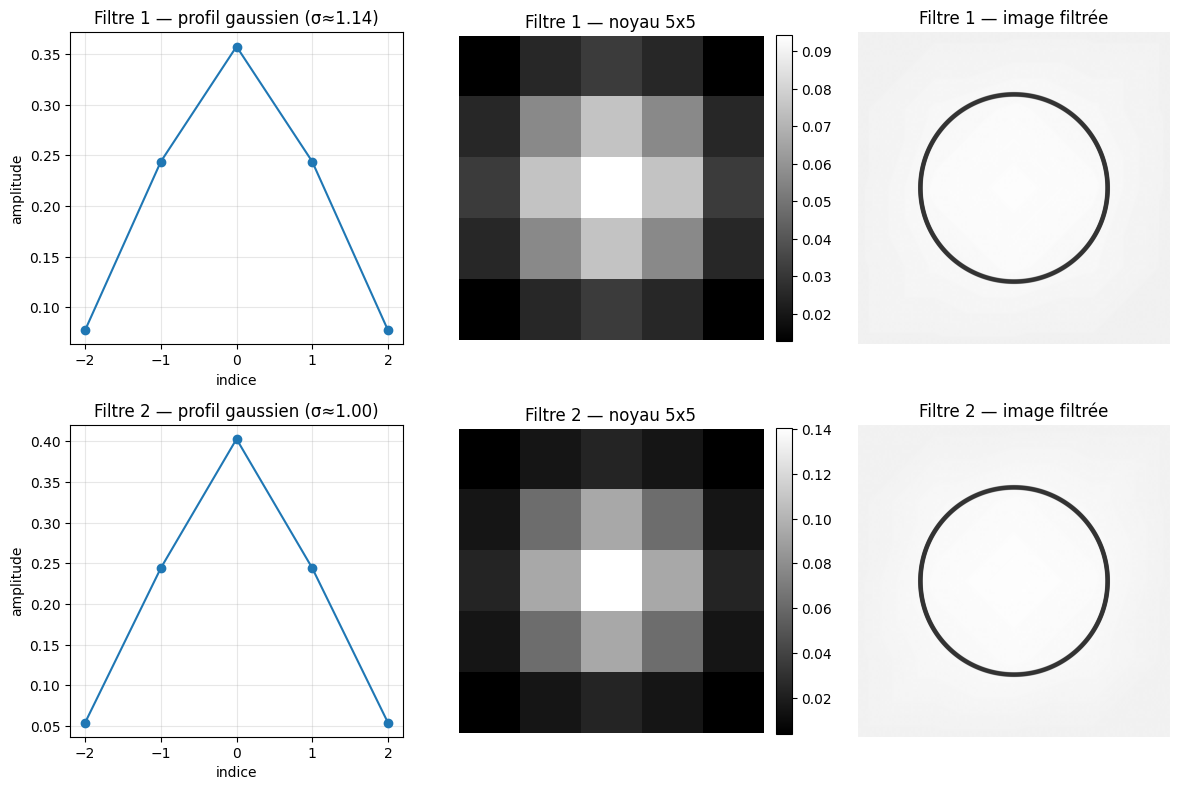

In [78]:
circle_gray = cv2.cvtColor(circle, cv2.COLOR_BGR2GRAY)

# =========================
# Filtre 1 
# =========================
K = (1 / 159) * np.array([[2,4,5,4,2],
                         [4,9,12,9,4],
                         [5,12,15,12,5],
                         [4,9,12,9,4],
                         [2,4,5,4,2]], dtype=np.float32)

print("la matrice du masque gaussien 5x5 (Filtre 1):\n", K)

x = np.arange(-2, 3)
row = K[K.shape[0] // 2]            # ligne centrale du masque 2D
row_prob = row / row.sum()          # renormalisée sur la ligne pour comparer les formes
mu = (x * row_prob).sum()           # moyenne
sigma = np.sqrt(((x - mu) ** 2 * row_prob).sum())  # écart-type

g5 = np.exp(-0.5 * (x / sigma) ** 2)  # gaussienne discrète
g5 = g5 / g5.sum()                    # normalisation

# application du filtre gaussien (Filtre 1)
circle_filtred_1 = convolve2d(circle_gray.astype(np.float32), K, mode='same', boundary='symm')
circle_filtred_1 = np.clip(circle_filtred_1, 0, 255).astype(np.uint8)

# =========================
# Filtre 2 
# =========================
H = np.array([1,4,6,4,1],dtype=np.float32)/16
I = np.outer(H,H)  # 5x5 , somme = 1

print("\nla matrice du masque gaussien 5x5 (Filtre 2):\n", I)

x2 = np.arange(-2, 3)
row2 = I[I.shape[0] // 2]
row_prob2 = row2 / row2.sum()

mu2 = (x2 * row_prob2).sum()
sigma2 = np.sqrt(((x2 - mu2) ** 2 * row_prob2).sum())

g5_2 = np.exp(-0.5 * (x2 / sigma2) ** 2)
g5_2 = g5_2 / g5_2.sum()

# application du filtre gaussien (Filtre 2)
circle_filtred_2 = convolve2d(circle_gray.astype(np.float32), I, mode='same', boundary='symm')
circle_filtred_2 = np.clip(circle_filtred_2, 0, 255).astype(np.uint8)

# =========================
# Affichages côte à côte
# =========================
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# --- Filtre 1 : profil 1D ---
axes[0, 0].plot(x, g5, marker="o")
axes[0, 0].set_title(f"Filtre 1 — profil gaussien (σ≈{sigma:.2f})")
axes[0, 0].set_xlabel("indice"); axes[0, 0].set_ylabel("amplitude")
axes[0, 0].grid(True, alpha=0.3)

# --- Filtre 1 : noyau 2D ---
im1 = axes[0, 1].imshow(K, cmap="gray")
axes[0, 1].set_title("Filtre 1 — noyau 5x5")
axes[0, 1].axis("off")
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

# --- Filtre 1 : image filtrée ---
axes[0, 2].imshow(circle_filtred_1, cmap="gray", vmin=0, vmax=255)
axes[0, 2].set_title("Filtre 1 — image filtrée")
axes[0, 2].axis("off")

# --- Filtre 2 : profil 1D ---
axes[1, 0].plot(x2, g5_2, marker="o")
axes[1, 0].set_title(f"Filtre 2 — profil gaussien (σ≈{sigma2:.2f})")
axes[1, 0].set_xlabel("indice"); axes[1, 0].set_ylabel("amplitude")
axes[1, 0].grid(True, alpha=0.3)

# --- Filtre 2 : noyau 2D ---
im2 = axes[1, 1].imshow(I, cmap="gray")
axes[1, 1].set_title("Filtre 2 — noyau 5x5")
axes[1, 1].axis("off")
fig.colorbar(im2, ax=axes[1, 1], fraction=0.046, pad=0.04)

# --- Filtre 2 : image filtrée ---
axes[1, 2].imshow(circle_filtred_2, cmap="gray", vmin=0, vmax=255)
axes[1, 2].set_title("Filtre 2 — image filtrée")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()


### 2. Contours par gradient + seuillage simple

Après le lissage gaussien, on calcule les **gradients** avec les filtres de Sobel, puis on applique un seuillage de la **magnitude** du gradient par un **percentile** pour ne garder que les bords les plus forts.

**percentile** par ex = 90 signifie qu'on garde 10% des valeurs les plus fortes  

**Filtres de Sobel (3×3)**
$
S_x=\begin{bmatrix}
-1&0&1\\
-2&0&2\\
-1&0&1
\end{bmatrix},\qquad
S_y=\begin{bmatrix}
1&2&1\\
0&0&0\\
-1&-2&-1
\end{bmatrix}
$

**Gradients horizontal et vertical** (par convolution) :<br><br>
$
G_x = I * S_x,\qquad G_y = I * S_y ,
$
<br>
où (I) est l’image lissée (ici ***I***= `circle_filtred_1`),<br> et (*) la convolution discrète.

**Magnitude du gradient** :
<br><br>
$
\operatorname{mag}(x,y)=\sqrt{,G_x(x,y)^2+G_y(x,y)^2}
$

**Seuil par percentile** <br><br>
On choisit un percentile $(p\in[80,95])$ (par ex. (p=90)) et on calcule le **seuil** (T) comme la valeur du $p$-ième percentile des magnitudes **non nulles** : <br><br>
$
\mathcal{M}= {\operatorname{mag}(x,y) | \operatorname{mag}(x,y)>0},\qquad
T=\operatorname{percentile}(\mathcal{M},p).
$

**Carte de contours binaire** :
$
E(x,y)=
\begin{cases}
255,& \text{si }\operatorname{mag}(x,y)\ge T,\\
0,& \text{sinon.}
\end{cases}
$


(np.float64(-0.5), np.float64(4999.5), np.float64(4999.5), np.float64(-0.5))

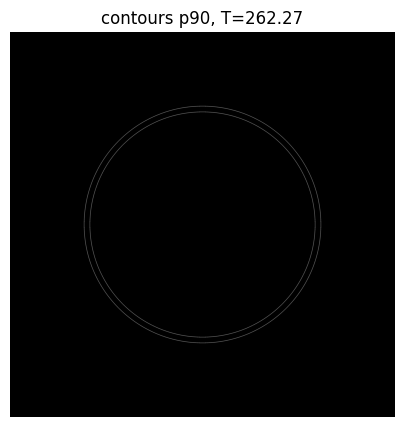

In [86]:
# 1) Gradients Sobel
Sx = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]], dtype=np.float32)
Sy = np.array([[ 1, 2, 1],
               [ 0, 0, 0],
               [-1,-2,-1]], dtype=np.float32)

Gx = convolve2d(circle_filtred_1.astype(np.float32), Sx, mode='same', boundary='symm')
Gy = convolve2d(circle_filtred_1.astype(np.float32), Sy, mode='same', boundary='symm')

# 2) Magnitude du gradient
mag = np.hypot(Gx, Gy) # racine carrée de (Gx² + Gy²)

# 3) Seuillage simple (percentile sur valeurs non nulles)
nz = mag[mag > 0]
p = 90  # essai : 80–95 selon le rendu
T = np.percentile(nz, p) if nz.size else 0.0 # seuil
edges = (mag >= T).astype(np.uint8) * 255

# 4) Affichage
fig, axes = plt.subplots(figsize=(5,5))
axes.imshow(edges, cmap='gray')
axes.set_title(f"contours p90, T={T:.2f}")
axes.axis('off')


### 3. Détection de cercles — Transformée de Hough (OpenCV)

#### **Objectif**  
Détecter automatiquement des cercles en laissant chaque **pixel de bord (les pixels blancs des contours)** voter pour des **centres** et des **rayons** probables.

#### **Modèle géométrique**
Un cercle de centre **(a,b)** et de rayon **r** vérifie :
$$
(x-a)^2 + (y-b)^2 = r^2
$$

#### **Intuition Hough (version à gradient)**
Après extraction des bords, chaque pixel **(x,y)** **situe le centre sur la normale** au bord.  
Si le gradient d’intensité est $(\nabla I=(G_x,G_y))$, alors un centre plausible s’écrit :
$$
(a,b)\;\approx\;(x,y)\;\pm\;r\,\frac{\nabla I}{\lVert \nabla I\rVert}
$$

On **vote** dans un accumulateur $(A[a,b,r])$. Les **pics** de $(A)$ désignent les cercles :
$$
(a^*,\,b^*,\,r^*)\;=\;\arg\max_{a,b,r}\;A[a,b,r]
$$


#### Pipeline minimal (ce que fait le code)
1) **Entrée** : image **lissée** en niveaux de gris (réduit le bruit et stabilise les bords).  
2) **Votes Hough** : `cv2.HoughCircles` remplit implicitement $(A[a,b,r])$ et renvoie les meilleurs cercles.  
3) **Overlay** : dessin de chaque cercle (un de même rayon que le cercle détecté et un au centre ) 


#### Paramètres essentiels (cheatsheet)
- `dp` — **décimation** de l’accumulateur (≈ 1.0 à 2.0).  
  Plus grand ⇒ accumulateur plus petit ⇒ plus rapide mais un peu moins précis.
  <br><br>
- `minDist` — **distance minimale** entre centres détectés.  
  Évite les doublons très proches.
  <br><br>
- `param1` — **seuil haut** du **Canny interne** (le bas vaut ≈ `param1/2`).  
  Plus grand ⇒ contours plus stricts.
  <br><br>
- `param2` — **seuil de vote** dans l’accumulateur.  
  Plus grand ⇒ **moins** de faux positifs, mais risque de rater des cercles faibles.
  <br><br>
- `minRadius`, `maxRadius` — **plage de rayons** testés.  
  Restreindre la plage ⇒ détection **plus stable** et **plus rapide**.

#### Réglage rapide
- **Trop de cercles** → augmenter `param2`, augmenter `minDist`, resserrer `minRadius/maxRadius`.  
- **Aucun cercle** → diminuer `param2`, élargir la plage de rayons, essayer `dp=1.0`.  
- **Bords irréguliers/bruyants** → lisser davantage (gaussien $(5\times5)$), améliorer contraste/éclairage.  
- **Entrée invalide** → s’assurer que l’image fournie à Hough est **grayscale** en **uint8** (0–255).


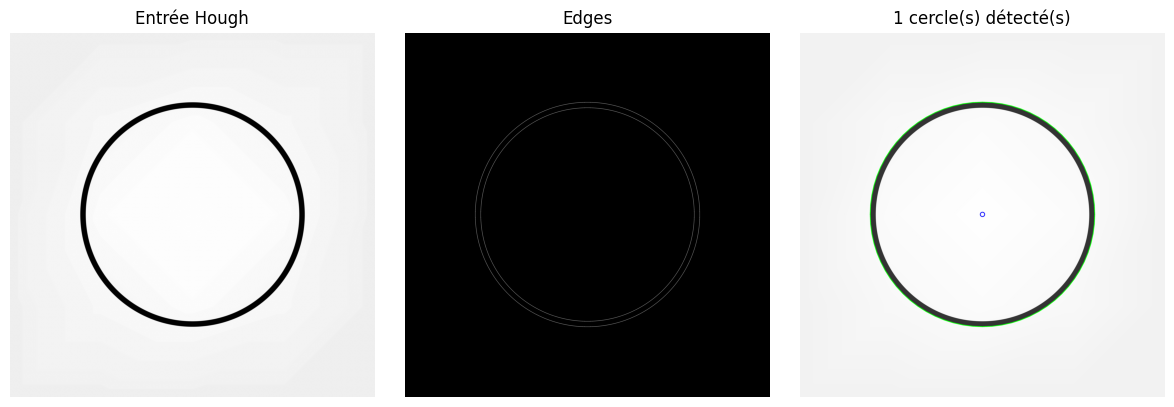

In [102]:

# 1) Image d'entrée pour Hough : prends la plus lissée si dispo
img_hough = circle_filtred_1
h, w = img_hough.shape

# 2) Hough cercles (OpenCV)
dp = 1.2                                # résolution de l'accumulateur (1–2 typique)
minDist = max(20, min(h, w) // 10)      # distance min entre centres
param1 = 120                             # seuil haut de Canny interne (100–200)
param2 = 60                              # seuil de l'accumulateur (↑=plus strict) ####Faire varier pour ajuster détection####
minRadius, maxRadius = 0, 0              # bornes des rayons (0=auto)

circles = cv2.HoughCircles(img_hough,
                           cv2.HOUGH_GRADIENT,
                           dp=dp,
                           minDist=minDist,
                           param1=param1,
                           param2=param2,
                           minRadius=minRadius,
                           maxRadius=maxRadius)

# 3) Overlay des cercles
overlay = circle.copy()                  # BGR
count = 0
if circles is not None:
    circles = np.round(circles[0]).astype(int)
    count = len(circles)
    for (x, y, r) in circles:
        cv2.circle(overlay, (x, y), r, (0, 255, 0), 10)   # cercle
        cv2.circle(overlay, (x, y), 30, (255, 0, 0), 10)  # centre

overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# 4) Affichage
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_hough, cmap='gray')
axes[0].set_title("Entrée Hough") 
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray', vmin=0, vmax=255) 
axes[1].set_title("Edges")
axes[1].axis('off')

axes[2].imshow(overlay_rgb)
axes[2].set_title(f"{count} cercle(s) détecté(s)")
axes[2].axis('off')

plt.tight_layout()
plt.show()
